In [4]:
#importing libraries

import pandas as pd
import numpy as np
import sqlite3
import re

In [21]:
df = pd.read_csv("../data/raw/nordtech_data.csv")
df.head()

,order_id,orderrad_id,orderdatum,leveransdatum,produkt_sku,produktnamn,kategori,antal,pris_per_enhet,region,kundtyp,betalmetod,kund_id,leveransstatus,recension_text,recensionsdatum,betyg
0,ORD-2024-00001,ORD-2024-00001-1,2024-05-19,2024-05-22,SKU-WC001,Webbkamera HD,Tillbehör,1,SEK 799,Uppsala,Privat,Kort,KND-53648,Levererad,NaN,NaN,NaN
1,ORD-2024-00002,ORD-2024-00002-1,2024-12-02,5 december 2024,SKU-HB001,USB-C Hub 7-port,Tillbehör,1,549.00,Göteborg,Privat,Swish,KND-84095,Levererad,NaN,NaN,NaN
2,ORD-2024-00003,ORD-2024-00003-1,2024-12-31,2025-01-03,SKU-SD001,Extern SSD 1TB,Lagring,1,1199.00,NaN,Företag,Faktura,KND-91748,Levererad,Stämmer inte överens med produktbeskrivningen.,2025-01-12,2.0
3,ORD-2024-00003,ORD-2024-00003-2,2024-12-31,2025-01-03,SKU-SD002,Extern SSD 500GB,Lagring,10,699 kr,Stockholm,Företag,FAKTURA,KND-91748,Mottagen,"Leveransen tog lite längre än utlovat, men pro...",2025-01-14,3.0
4,ORD-2024-00003,ORD-2024-00003-3,2024-12-31,2025-01-03,SKU-MS001,Trådlös Mus X1,Tillbehör,1,399.00,Stockholm,Företag,Faktura,KND-91748,NaN,NaN,NaN,NaN


In [22]:

def clean_text_missing(series):
    return series.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})

def clean_currency(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("SEK", "", regex=False)
    s = s.str.replace("kr", "", regex=False)
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

def clean_quantity(series):
    s = series.astype(str).str.strip()
    s = s.str.replace(" ", "", regex=False)
    s = s.str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

def clean_swedish_dates(series):
    s = clean_text_missing(series)

    month_map = {
        "januari": "January",
        "februari": "February",
        "mars": "March",
        "april": "April",
        "maj": "May",
        "juni": "June",
        "juli": "July",
        "augusti": "August",
        "september": "September",
        "oktober": "October",
        "november": "November",
        "december": "December"
    }

    for sv, en in month_map.items():
        s = s.str.replace(sv, en, case=False, regex=False)

    return pd.to_datetime(s, errors="coerce")

def normalize_categories(df):
    if "betalmetod" in df.columns:
        df["betalmetod"] = clean_text_missing(df["betalmetod"]).str.title()

    if "leveransstatus" in df.columns:
        df["leveransstatus"] = clean_text_missing(df["leveransstatus"]).str.title()

    if "region" in df.columns:
        df["region"] = clean_text_missing(df["region"]).str.title()

    if "kundtyp" in df.columns:
        df["kundtyp"] = clean_text_missing(df["kundtyp"]).str.title()

    return df

def clean_and_transform(df):
    df = df.copy()

    # Keep raw copies for auditing
    for col in ["orderdatum", "leveransdatum", "antal", "pris_per_enhet"]:
        df[f"{col}_raw"] = df[col]

    # Review fields: missing means no review submitted
    if "recension_text" in df.columns:
        df["recension_text"] = clean_text_missing(df["recension_text"])
        df["has_review"] = df["recension_text"].notna()
    else:
        df["has_review"] = False

    if "recensionsdatum" in df.columns:
        df["recensionsdatum"] = clean_text_missing(df["recensionsdatum"])
        df["recensionsdatum"] = clean_swedish_dates(df["recensionsdatum"])

    # Clean core fields before coercion
    df["orderdatum"] = clean_swedish_dates(df["orderdatum"])
    df["leveransdatum"] = clean_swedish_dates(df["leveransdatum"])
    df["antal"] = clean_quantity(df["antal"])
    df["pris_per_enhet"] = clean_currency(df["pris_per_enhet"])

    # Normalize text categories
    df = normalize_categories(df)

    # Validation flags
    df["invalid_order_date"] = df["orderdatum"].isna()
    df["invalid_delivery_date"] = df["leveransdatum"].isna()
    df["invalid_quantity"] = df["antal"].isna() | (df["antal"] <= 0)
    df["invalid_price"] = df["pris_per_enhet"].isna() | (df["pris_per_enhet"] <= 0)
    df["invalid_lead_time"] = (
        df["orderdatum"].notna()
        & df["leveransdatum"].notna()
        & (df["leveransdatum"] < df["orderdatum"])
    )

    # Drop only truly unusable rows
    critical_invalid = (
        df["invalid_order_date"]
        | df["invalid_delivery_date"]
        | df["invalid_quantity"]
        | df["invalid_price"]
    )

    df_clean = df.loc[~critical_invalid].copy()

    # Feature engineering
    df_clean["revenue"] = df_clean["antal"] * df_clean["pris_per_enhet"]
    df_clean["lead_time_days"] = (df_clean["leveransdatum"] - df_clean["orderdatum"]).dt.days
    df_clean["order_weekday"] = df_clean["orderdatum"].dt.day_name()
    df_clean["order_month"] = df_clean["orderdatum"].dt.month

    return df_clean

In [24]:
df_clean = clean_and_transform(df)

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Dropped rows:", len(df) - len(df_clean))
print("Drop percentage:", round((len(df) - len(df_clean)) / len(df) * 100, 2), "%")

df_clean.head()

Original rows: 2767
Clean rows: 2236
Dropped rows: 531
Drop percentage: 19.19 %


,order_id,orderrad_id,orderdatum,leveransdatum,produkt_sku,produktnamn,kategori,antal,pris_per_enhet,region,...,has_review,invalid_order_date,invalid_delivery_date,invalid_quantity,invalid_price,invalid_lead_time,revenue,lead_time_days,order_weekday,order_month
0,ORD-2024-00001,ORD-2024-00001-1,2024-05-19,2024-05-22,SKU-WC001,Webbkamera HD,Tillbehör,1.0,799.0,Uppsala,...,False,False,False,False,False,False,799.0,3,Sunday,5
2,ORD-2024-00003,ORD-2024-00003-1,2024-12-31,2025-01-03,SKU-SD001,Extern SSD 1TB,Lagring,1.0,1199.0,NaN,...,True,False,False,False,False,False,1199.0,3,Tuesday,12
3,ORD-2024-00003,ORD-2024-00003-2,2024-12-31,2025-01-03,SKU-SD002,Extern SSD 500GB,Lagring,10.0,699.0,Stockholm,...,True,False,False,False,False,False,6990.0,3,Tuesday,12
4,ORD-2024-00003,ORD-2024-00003-3,2024-12-31,2025-01-03,SKU-MS001,Trådlös Mus X1,Tillbehör,1.0,399.0,Stockholm,...,False,False,False,False,False,False,399.0,3,Tuesday,12
6,ORD-2024-00005,ORD-2024-00005-1,2024-07-01,2024-07-05,SKU-HB001,USB-C Hub 7-port,Tillbehör,10.0,549.0,Örebro,...,False,False,False,False,False,False,5490.0,4,Monday,7


In [25]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2236 entries, 0 to 2766
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               2236 non-null   str           
 1   orderrad_id            2236 non-null   str           
 2   orderdatum             2236 non-null   datetime64[us]
 3   leveransdatum          2236 non-null   datetime64[us]
 4   produkt_sku            2236 non-null   str           
 5   produktnamn            2236 non-null   str           
 6   kategori               2236 non-null   str           
 7   antal                  2236 non-null   float64       
 8   pris_per_enhet         2236 non-null   float64       
 9   region                 2108 non-null   str           
 10  kundtyp                2236 non-null   str           
 11  betalmetod             2137 non-null   str           
 12  kund_id                2236 non-null   str           
 13  leveransstatus     

In [26]:
df_clean[["orderdatum_raw", "orderdatum", "pris_per_enhet_raw", "pris_per_enhet", "antal_raw", "antal"]].head(10)

,orderdatum_raw,orderdatum,pris_per_enhet_raw,pris_per_enhet,antal_raw,antal
0,2024-05-19,2024-05-19,SEK 799,799.0,1,1.0
2,2024-12-31,2024-12-31,1199.00,1199.0,1,1.0
3,2024-12-31,2024-12-31,699 kr,699.0,10,10.0
4,2024-12-31,2024-12-31,399.00,399.0,1,1.0
6,2024-07-01,2024-07-01,549.00,549.0,10,10.0
7,2024-07-01,2024-07-01,1899.00,1899.0,3,3.0
8,2024-07-01,2024-07-01,599.00,599.0,2,2.0
9,2024-07-01,2024-07-01,399.00,399.0,3,3.0
10,2024-03-10,2024-03-10,4999.00,4999.0,2,2.0
11,2024-06-16,2024-06-16,5999.00,5999.0,2,2.0


In [27]:
df_clean[["invalid_order_date", "invalid_delivery_date", "invalid_quantity", "invalid_price", "invalid_lead_time"]].sum()

invalid_order_date        0
invalid_delivery_date     0
invalid_quantity          0
invalid_price             0
invalid_lead_time        51
dtype: int64

In [28]:
df_analysis = df_clean.loc[~df_clean["invalid_lead_time"]].copy()

print("Rows in df_clean:", len(df_clean))
print("Rows in df_analysis:", len(df_analysis))
print("Excluded invalid lead time rows:", df_clean["invalid_lead_time"].sum())

Rows in df_clean: 2236
Rows in df_analysis: 2185
Excluded invalid lead time rows: 51


In [29]:
print("Rows with review text:", df_analysis["has_review"].sum())
print("Rows without review text:", (~df_analysis["has_review"]).sum())

Rows with review text: 1077
Rows without review text: 1108


In [30]:
df_analysis.loc[df_analysis["has_review"], ["recension_text", "betyg"]].head(10)

,recension_text,betyg
2,Stämmer inte överens med produktbeskrivningen.,2.0
3,"Leveransen tog lite längre än utlovat, men pro...",3.0
7,Medelmåttig upplevelse.,3.0
10,Prisvärt och bra kvalitet. Kommer köpa igen.,4.0
12,Dålig kundservice när jag försökte reklamera.,1.0
13,För dyrt för vad man får.,2.0
21,Riktigt nöjd! Använder den dagligen.,4.0
24,Mycket nöjd med köpet. Snabb leverans också!,4.0
27,Snabb leverans och produkten är fantastisk!,4.0
28,Produkten var trasig vid leverans. Besviken.,1.0


In [31]:
df_reviews = df_analysis.loc[df_analysis["has_review"]].copy()

print("Rows with reviews:", len(df_reviews))
df_reviews[["recension_text", "betyg"]].head()

Rows with reviews: 1077


,recension_text,betyg
2,Stämmer inte överens med produktbeskrivningen.,2.0
3,"Leveransen tog lite längre än utlovat, men pro...",3.0
7,Medelmåttig upplevelse.,3.0
10,Prisvärt och bra kvalitet. Kommer köpa igen.,4.0
12,Dålig kundservice när jag försökte reklamera.,1.0


In [32]:
from transformers import pipeline

/Users/arnisagjoka/Desktop/NordTech-Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10960.72it/s]


In [34]:
sample_reviews = df_reviews["recension_text"].head(5).tolist()

for review in sample_reviews:
    result = sentiment_model(str(review)[:512])
    print("Review:", review)
    print("Prediction:", result)
    print("-" * 50)

Review: Stämmer inte överens med produktbeskrivningen.
Prediction: [{'label': '1 star', 'score': 0.4112416207790375}]
--------------------------------------------------
Review: Leveransen tog lite längre än utlovat, men produkten är ok.
Prediction: [{'label': '3 stars', 'score': 0.6634324193000793}]
--------------------------------------------------
Review: Medelmåttig upplevelse.
Prediction: [{'label': '5 stars', 'score': 0.36392465233802795}]
--------------------------------------------------
Review: Prisvärt och bra kvalitet. Kommer köpa igen.
Prediction: [{'label': '5 stars', 'score': 0.6654770374298096}]
--------------------------------------------------
Review: Dålig kundservice när jag försökte reklamera.
Prediction: [{'label': '2 stars', 'score': 0.524247407913208}]
--------------------------------------------------


In [35]:
def map_bert_sentiment(text):
    if pd.isna(text):
        return np.nan

    result = sentiment_model(str(text)[:512])[0]["label"]
    stars = int(result[0])

    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

In [36]:
df_reviews_sample = df_reviews.head(20).copy()
df_reviews_sample["sentiment_bert"] = df_reviews_sample["recension_text"].apply(map_bert_sentiment)

df_reviews_sample[["recension_text", "betyg", "sentiment_bert"]]

,recension_text,betyg,sentiment_bert
2,Stämmer inte överens med produktbeskrivningen.,2.0,Negative
3,"Leveransen tog lite längre än utlovat, men pro...",3.0,Neutral
7,Medelmåttig upplevelse.,3.0,Positive
10,Prisvärt och bra kvalitet. Kommer köpa igen.,4.0,Positive
12,Dålig kundservice när jag försökte reklamera.,1.0,Negative
13,För dyrt för vad man får.,2.0,Neutral
21,Riktigt nöjd! Använder den dagligen.,4.0,Positive
24,Mycket nöjd med köpet. Snabb leverans också!,4.0,Positive
27,Snabb leverans och produkten är fantastisk!,4.0,Positive
28,Produkten var trasig vid leverans. Besviken.,1.0,Neutral


In [37]:
df_reviews["sentiment_bert"] = df_reviews["recension_text"].apply(map_bert_sentiment)

In [38]:
df_reviews["sentiment_bert"].value_counts(dropna=False)
df_reviews[["recension_text", "betyg", "sentiment_bert"]].head(15)

,recension_text,betyg,sentiment_bert
2,Stämmer inte överens med produktbeskrivningen.,2.0,Negative
3,"Leveransen tog lite längre än utlovat, men pro...",3.0,Neutral
7,Medelmåttig upplevelse.,3.0,Positive
10,Prisvärt och bra kvalitet. Kommer köpa igen.,4.0,Positive
12,Dålig kundservice när jag försökte reklamera.,1.0,Negative
13,För dyrt för vad man får.,2.0,Neutral
21,Riktigt nöjd! Använder den dagligen.,4.0,Positive
24,Mycket nöjd med köpet. Snabb leverans också!,4.0,Positive
27,Snabb leverans och produkten är fantastisk!,4.0,Positive
28,Produkten var trasig vid leverans. Besviken.,1.0,Neutral


In [39]:
df_analysis = df_analysis.merge(
    df_reviews[["orderrad_id", "sentiment_bert"]],
    on="orderrad_id",
    how="left"
)

In [40]:
df_analysis["sentiment_bert"].value_counts(dropna=False)
df_analysis.loc[df_analysis["has_review"], ["recension_text", "betyg", "sentiment_bert"]].head(15)

,recension_text,betyg,sentiment_bert
1,Stämmer inte överens med produktbeskrivningen.,2.0,Negative
2,"Leveransen tog lite längre än utlovat, men pro...",3.0,Neutral
5,Medelmåttig upplevelse.,3.0,Positive
8,Prisvärt och bra kvalitet. Kommer köpa igen.,4.0,Positive
10,Dålig kundservice när jag försökte reklamera.,1.0,Negative
11,För dyrt för vad man får.,2.0,Neutral
17,Riktigt nöjd! Använder den dagligen.,4.0,Positive
20,Mycket nöjd med köpet. Snabb leverans också!,4.0,Positive
22,Snabb leverans och produkten är fantastisk!,4.0,Positive
23,Produkten var trasig vid leverans. Besviken.,1.0,Neutral


In [41]:
pd.crosstab(df_reviews["betyg"], df_reviews["sentiment_bert"])

sentiment_bert,Negative,Neutral,Positive
betyg,,,
1.0,73,20,10
2.0,69,16,3
3.0,0,159,39
4.0,23,0,325
5.0,19,0,321


Sentimentanalysen genomfördes med en BERT-baserad flerspråkig modell på recensionstexten.
Detta gav en mer textnära analys än att härleda sentiment enbart från betyg.
Saknade recensioner lämnades som tomma värden och tolkades inte som okänt sentiment.

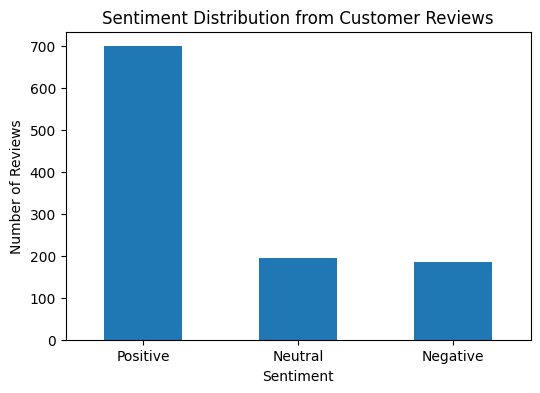

In [42]:
import matplotlib.pyplot as plt

sentiment_counts = df_reviews["sentiment_bert"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution from Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.show()

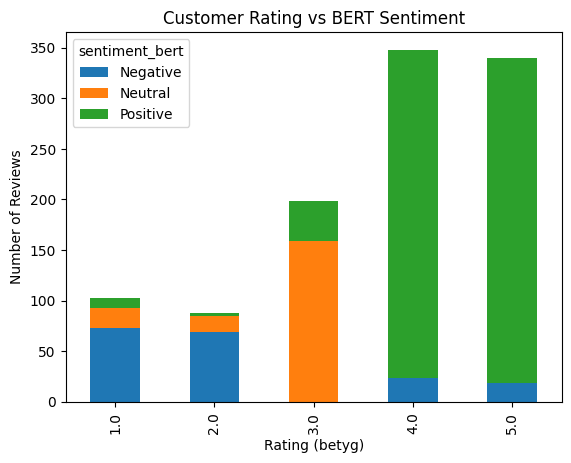

In [43]:
pd.crosstab(df_reviews["betyg"], df_reviews["sentiment_bert"]).plot(kind="bar", stacked=True)

plt.title("Customer Rating vs BERT Sentiment")
plt.xlabel("Rating (betyg)")
plt.ylabel("Number of Reviews")

plt.show()

In [44]:
df_analysis.to_csv("../data/processed/nordtech_cleaned_with_sentiment.csv", index=False)